In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#LOAD THE DATASET -ENCODING='ISO-8859-1' HANDLES THE SPECIAL CHARACTERS
df = pd.read_csv('../data/data.csv', encoding='ISO-8859-1')

print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
#CHECK DATA QUALITY-MISSING VALUES AND DATA TYPES
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB
None

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [3]:
#BASIC STATISTICS-UNDERSTAND THE NUMBERS
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
#STEP 1 - REMOVE ROWS WITH MISSING CUSTOMERID
#WE NEED CUSTOMERID FOR CUSTOMER ANALYSIS
df_clean = df.dropna(subset=['CustomerID'])
print("Rows after removing missing CustomerID:", len(df_clean))

Rows after removing missing CustomerID: 406829


In [5]:
#STEP 2 - REMOVE CANCELLATIONS(INVOICENO STARTING WITH 'C)
#AND NEGATIVE QUANTITIES (RETURNS/ERRORS)
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print("Rows after cleaning:", len(df_clean))

Rows after cleaning: 397884


In [6]:
# Step 3 — Convert InvoiceDate from text to a real date
# So we can do monthly analysis later
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Step 4 — Add a TotalPrice column (Quantity x UnitPrice)
# This is revenue per line item — you'll need this constantly
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("New columns:", df_clean.columns.tolist())
print("Date range:", df_clean['InvoiceDate'].min(), "to", df_clean['InvoiceDate'].max())
df_clean.head()

New columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


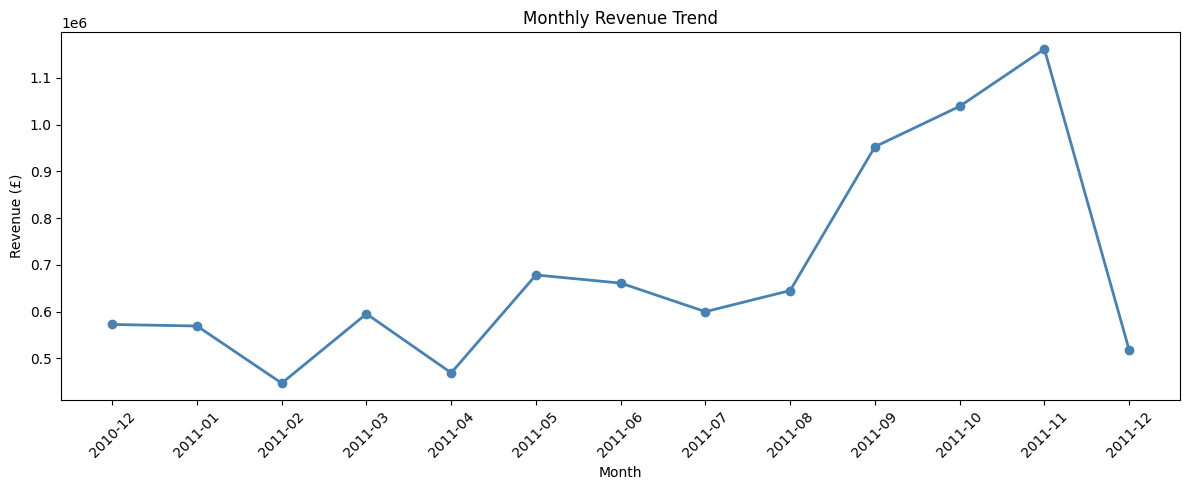

In [7]:
# Extract month-year from the date
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

# Total revenue per month
monthly_revenue = df_clean.groupby('Month')['TotalPrice'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

# Plot it
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['Month'], monthly_revenue['TotalPrice'], 
         marker='o', linewidth=2, color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

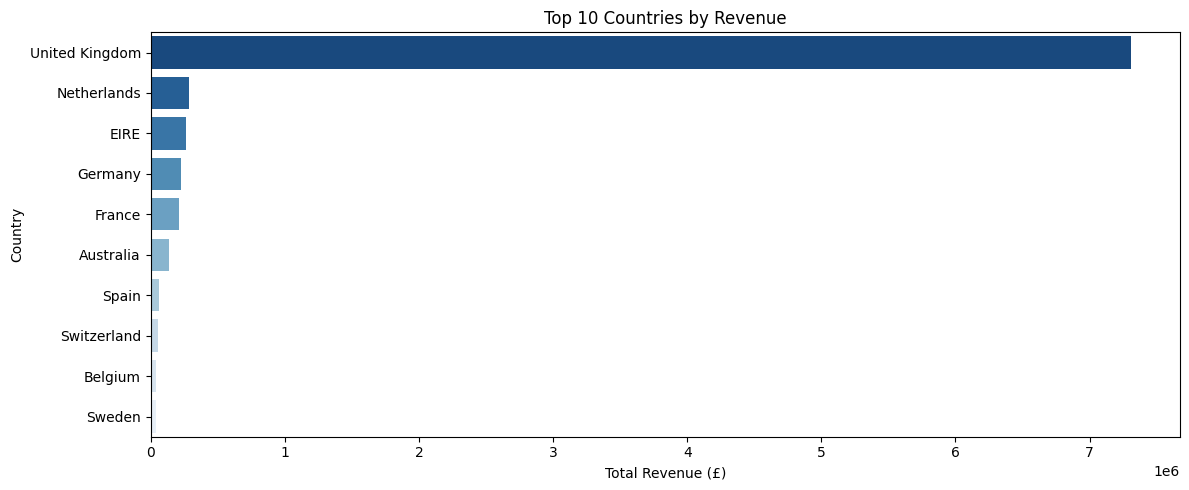

In [10]:
country_revenue = df_clean.groupby('Country')['TotalPrice'].sum()
country_revenue = country_revenue.sort_values(ascending=False).head(10).reset_index()
country_revenue.columns = ['Country', 'Revenue']

plt.figure(figsize=(12, 5))
sns.barplot(data=country_revenue, x='Revenue', y='Country', 
            hue='Country', palette='Blues_r', legend=False)
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

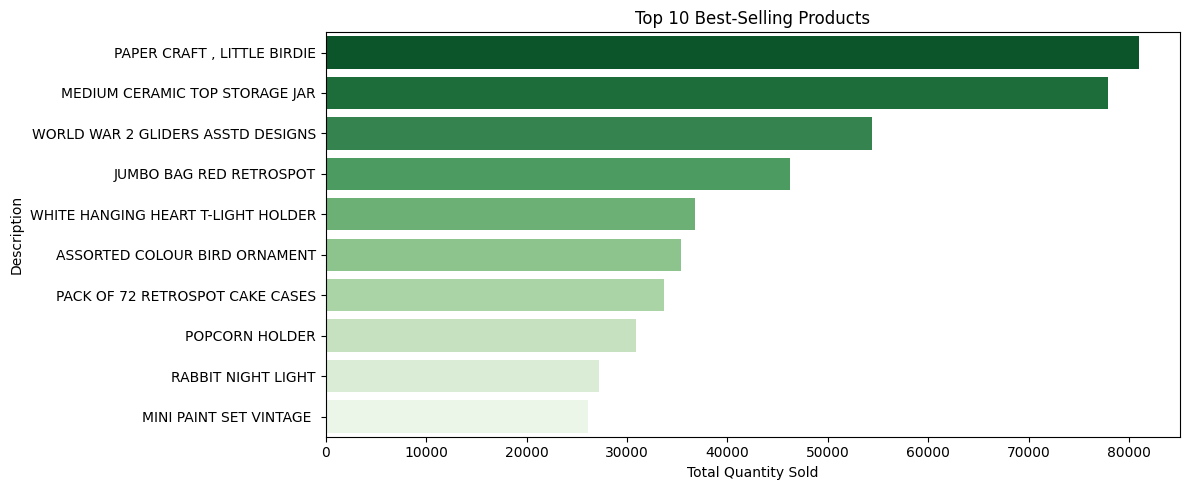

In [11]:
top_products = df_clean.groupby('Description')['Quantity'].sum()
top_products = top_products.sort_values(ascending=False).head(10).reset_index()
top_products.columns = ['Description', 'Quantity']

plt.figure(figsize=(12, 5))
sns.barplot(data=top_products, x='Quantity', y='Description',
            hue='Description', palette='Greens_r', legend=False)
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

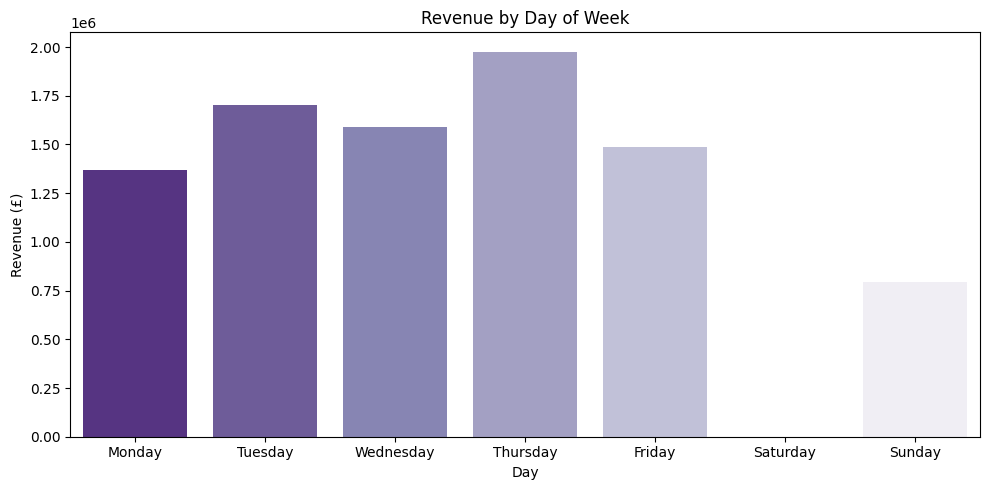

In [13]:
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_revenue = df_clean.groupby('DayOfWeek')['TotalPrice'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=day_revenue.index, y=day_revenue.values,
            hue=day_revenue.index, palette='Purples_r', legend=False)
plt.title('Revenue by Day of Week')
plt.xlabel('Day')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

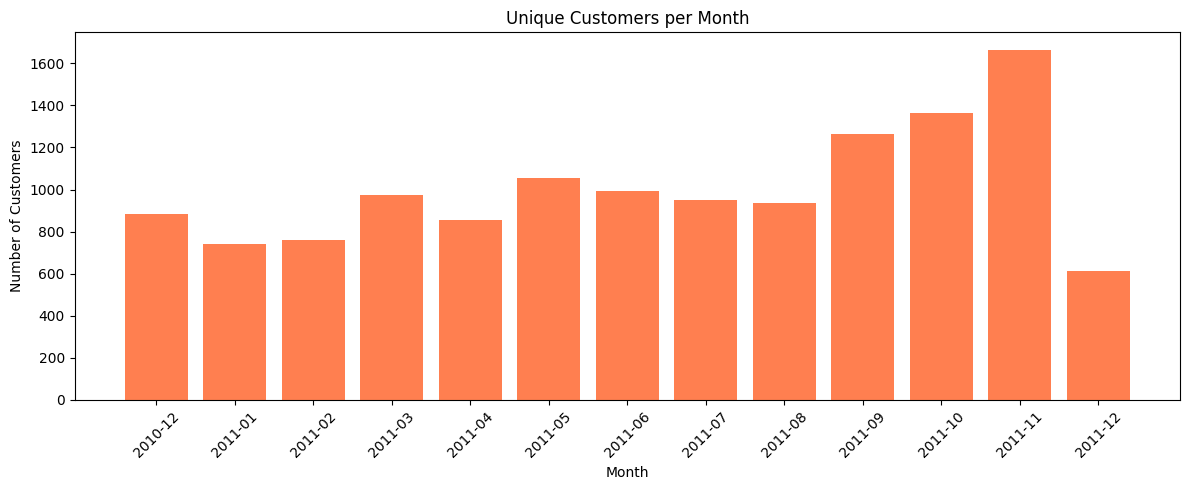

In [14]:
monthly_customers = df_clean.groupby('Month')['CustomerID'].nunique().reset_index()
monthly_customers['Month'] = monthly_customers['Month'].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(monthly_customers['Month'], monthly_customers['CustomerID'], color='coral')
plt.title('Unique Customers per Month')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

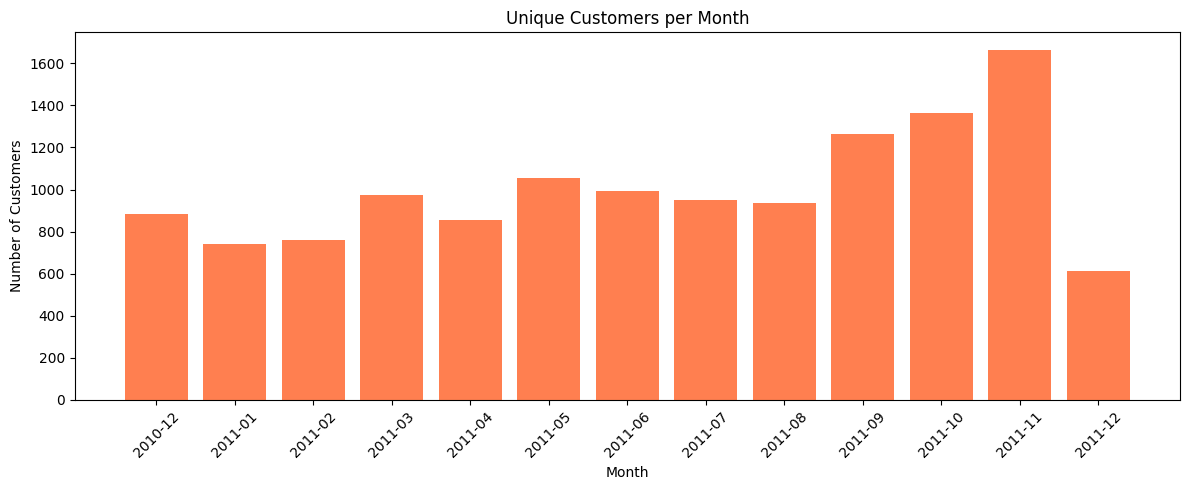

In [15]:
monthly_customers = df_clean.groupby('Month')['CustomerID'].nunique().reset_index()
monthly_customers['Month'] = monthly_customers['Month'].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(monthly_customers['Month'], monthly_customers['CustomerID'], color='coral')
plt.title('Unique Customers per Month')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()